# Project: Image Denoising using Autoencoders
In this project, build a Convolutional Autoencoder to remove noise from the MNIST digits dataset. The goal is to train a model that takes a noisy image as input and reconstructs the original, clean version.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize the pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to (28, 28, 1) for convolutional layers
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f'Training shape: {x_train.shape}')
print(f'Testing shape: {x_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


### 1. Adding Noise
We will inject random Gaussian noise into our images to create the 'noisy' dataset.

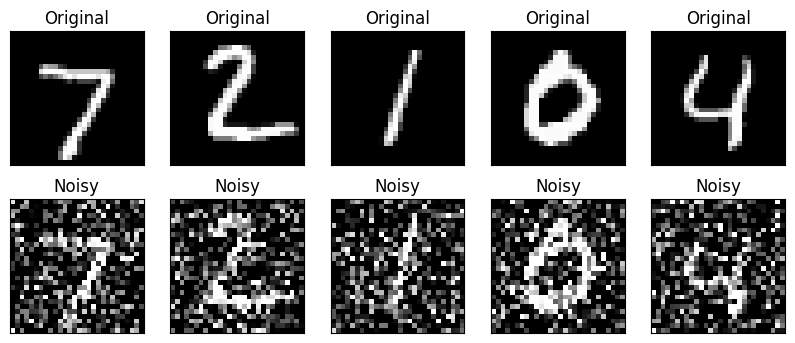

In [2]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to stay within [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Visualize noisy vs original
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### 2. Building the Autoencoder
We use a Convolutional Neural Network (CNN) architecture. The **Encoder** reduces the spatial dimensions, and the **Decoder** restores them.

In [3]:
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### 2b. Advanced Architecture: Residual Denoising Autoencoder
Instead of a simple bottleneck, we use a Residual connection. This allows the model to learn the 'residual' noise and subtract it, often leading to much sharper reconstructions.

In [6]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([shortcut, x])
    return layers.Activation('relu')(x)

input_img_res = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), padding='same')(input_img_res)

# Encoder with Residual Blocks
x = residual_block(x, 32)
x = layers.MaxPooling2D((2, 2))(x)
x = residual_block(x, 32)

# Decoder
x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)
res_autoencoder = models.Model(input_img_res, layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x))

res_autoencoder.compile(optimizer='adam', loss='mse')
res_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ conv2d_3[0][0],   │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │      9,248 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 14, 14,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 14, 14,    │          0 │ max_pooling2d_2[… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 14, 14,    │          0 │ add_1[0][0]     

 Total params: 47,361 (185.00 KB)

 Trainable params: 47,105 (184.00 KB)

 Non-trainable params: 256 (1.00 KB)

### 3. Training the Model
We train the model to map `x_train_noisy` back to the original `x_train`.

In [4]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.1860 - val_loss: 0.1189
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1152 - val_loss: 0.1108
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1100 - val_loss: 0.1077
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1073 - val_loss: 0.1053
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1054 - val_loss: 0.1040
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1040 - val_loss: 0.1027
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1029 - val_loss: 0.1018
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1019 - val_loss: 0.1013
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1012 - val_loss: 0.1004
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1006 - val_loss: 0.0997


### 3b. Performance Analytics
Let's visualize the training history to check for overfitting or convergence issues.

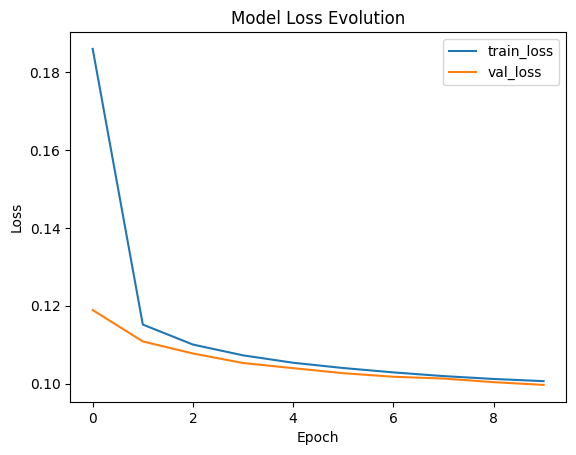

In [7]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss Evolution')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### 5. Stress Testing: Denoising at Variable Noise Levels
Let's test how robust the trained model is by increasing the `noise_factor` dynamically and measuring the reconstruction error (MSE).

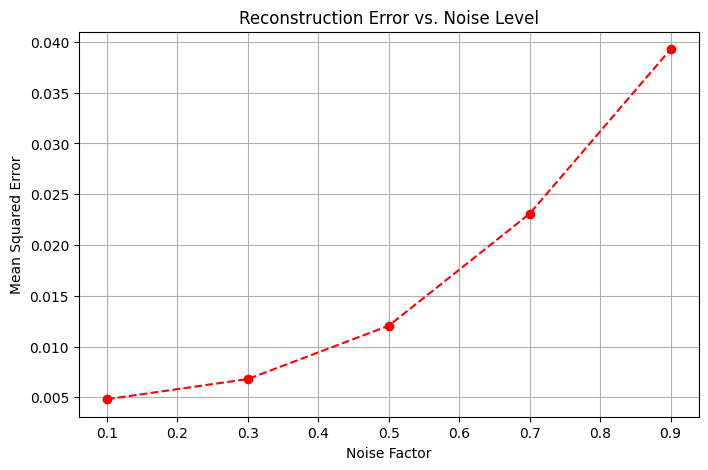

In [8]:
noise_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for nf in noise_levels:
    # Create test samples with varying noise
    noisy_temp = x_test + nf * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
    noisy_temp = np.clip(noisy_temp, 0., 1.)

    # Predict and calculate Mean Squared Error
    denoised = autoencoder.predict(noisy_temp, verbose=0)
    mse = np.mean(np.square(x_test - denoised))
    results.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, results, marker='o', linestyle='--', color='red')
plt.title('Reconstruction Error vs. Noise Level')
plt.xlabel('Noise Factor')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

### 4. Denoising Results
Let's see how well the model removes noise from the test set.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


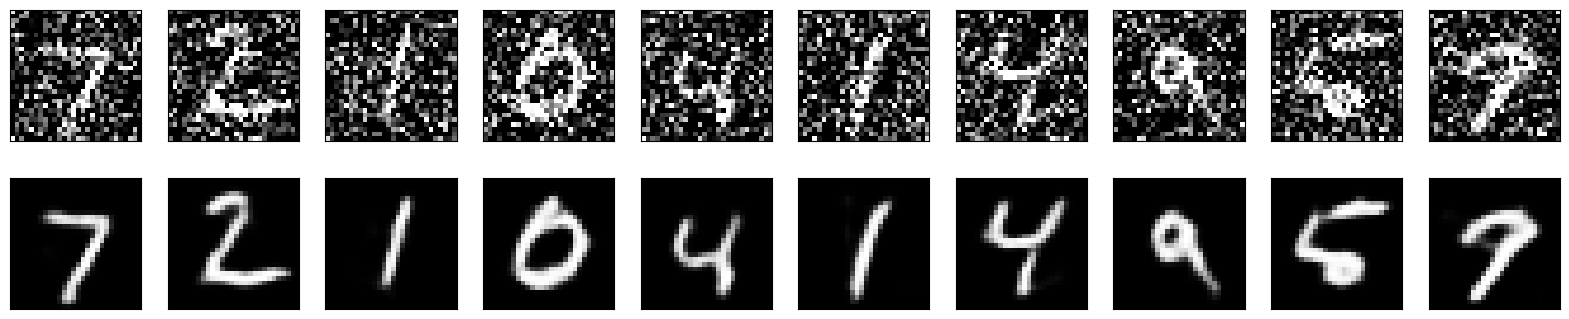

In [5]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Noisy input
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Denoised output
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### 5. Robustness Analysis: Variable Noise Stress Test
A robust model should handle varying degrees of noise. Here, we evaluate how the Mean Squared Error (MSE) increases as we scale the noise factor from 0.1 to 0.9.

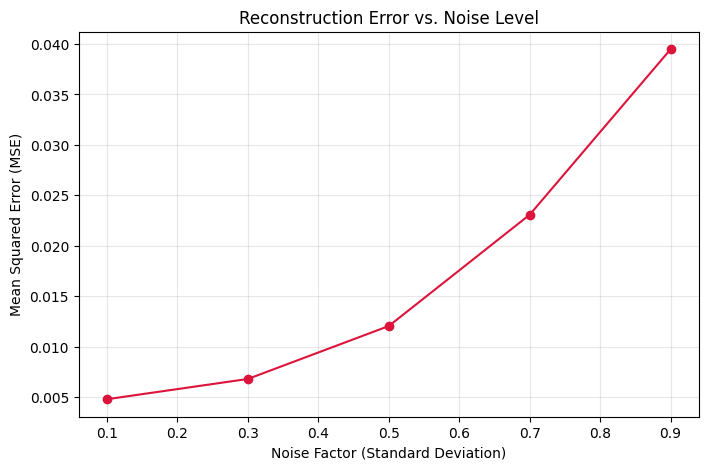

In [9]:
noise_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for nf in noise_levels:
    # Generate temporary noisy data
    noisy_temp = x_test + nf * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
    noisy_temp = np.clip(noisy_temp, 0., 1.)

    # Predict and calculate error compared to original clean image
    denoised = autoencoder.predict(noisy_temp, verbose=0)
    mse = np.mean(np.square(x_test - denoised))
    results.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, results, marker='o', linestyle='-', color='crimson')
plt.title('Reconstruction Error vs. Noise Level')
plt.xlabel('Noise Factor (Standard Deviation)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(alpha=0.3)
plt.show()

### 6. Visualizing the Latent Space Clusters
One of the most powerful aspects of an autoencoder is its ability to learn a compressed representation. Here, we use t-SNE to project the encoder's output into a 2D plane to visualize how the model clusters different digits.

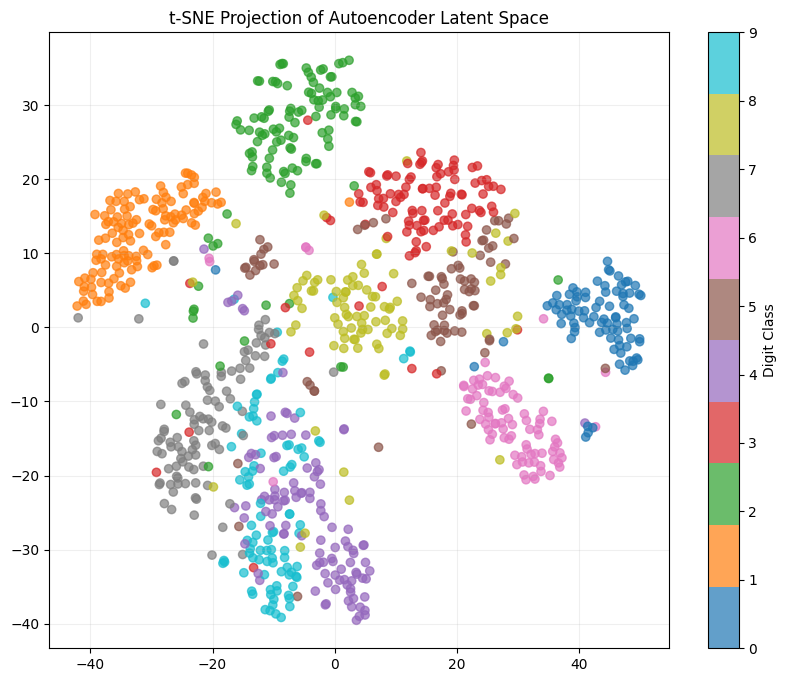

In [11]:
from sklearn.manifold import TSNE

# Extract the encoder part of the autoencoder
encoder_model = models.Model(input_img, encoded)

# Get latent representations for test data
encoded_imgs = encoder_model.predict(x_test, verbose=0)
flat_encoded = encoded_imgs.reshape(len(encoded_imgs), -1)

# Limit to 1000 samples for faster t-SNE computation
n_samples = 1000
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d = tsne.fit_transform(flat_encoded[:n_samples])

# Plot the results using the actual digit labels for color
(_, y_test_labels) = mnist.load_data()[1]
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y_test_labels[:n_samples], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit Class')
plt.title('t-SNE Projection of Autoencoder Latent Space')
plt.grid(True, alpha=0.2)
plt.show()

### 6. Exploring the Latent Space (Generative Aspect)
To truly explore every aspect, we must look at the 'Bottleneck'. We will use the encoder to project our digits into a 2D space to see how the model clusters different numbers (0-9) based on their features.

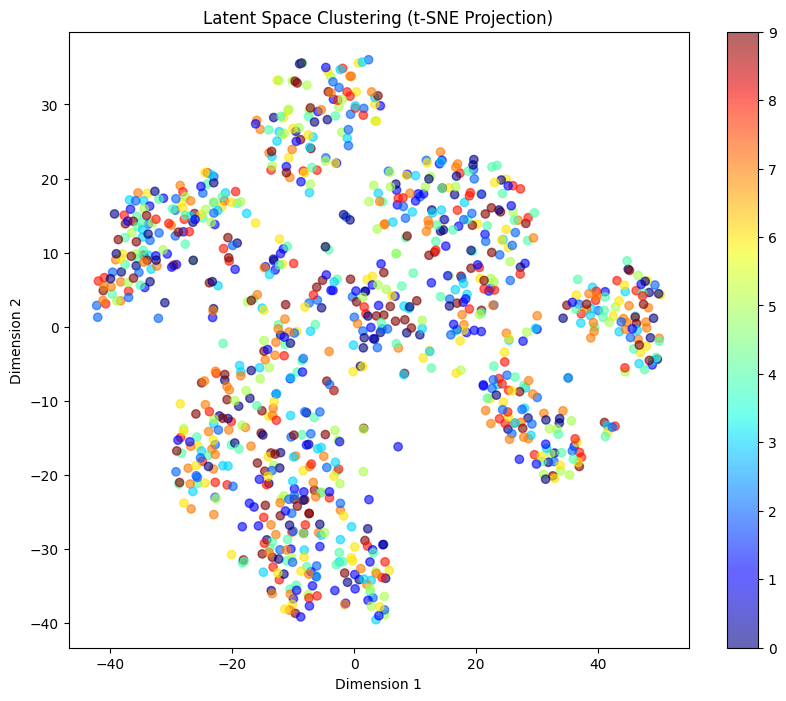

In [10]:
# We will create a smaller encoder to extract the 2D latent representations
latent_encoder = models.Model(input_img, encoded)

# Project test digits into the latent space
# Note: Since our encoder output is (7, 7, 32), we flatten it for visualization
# For a true 2D plot, we apply PCA or t-SNE
from sklearn.manifold import TSNE

encoded_preds = latent_encoder.predict(x_test, verbose=0)
flat_encoded = encoded_preds.reshape(len(encoded_preds), -1)

# Reduce to 2 dimensions for plotting
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latent_2d = tsne.fit_transform(flat_encoded[:1000]) # Plotting first 1000 for speed

# Plot the clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=mnist.load_data()[0][1][:1000], cmap='jet', alpha=0.6)
plt.colorbar(scatter)
plt.title('Latent Space Clustering (t-SNE Projection)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

### 7. Final Challenge: Super-Resolution Denoising
In this task, we downsample the noisy images to 14x14 (Low Res). The autoencoder must learn to remove noise while simultaneously upsampling the image back to 28x28 using `UpSampling2D` or `Conv2DTranspose` layers.

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.1146
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1120
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1120
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1120
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1120
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


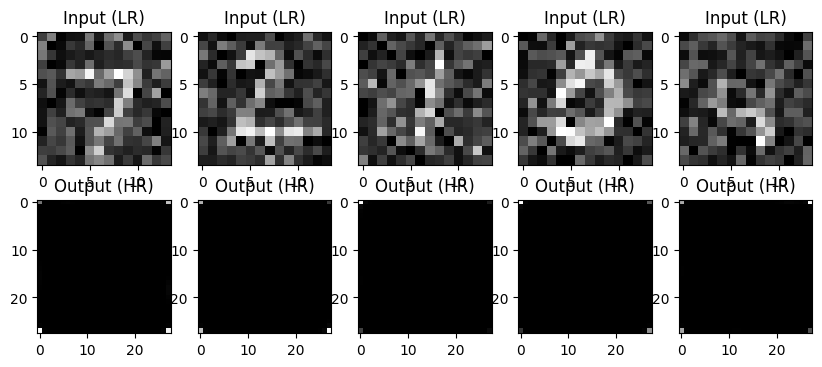

In [12]:
# 1. Create Low-Res Noisy Data (14x14)
x_train_lr = tf.image.resize(x_train_noisy, [14, 14]).numpy()
x_test_lr = tf.image.resize(x_test_noisy, [14, 14]).numpy()

# 2. Build Super-Res Autoencoder
sr_input = layers.Input(shape=(14, 14, 1))
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(sr_input)
x = layers.UpSampling2D((2, 2))(x) # Upscale to 28x28
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
sr_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

sr_autoencoder = models.Model(sr_input, sr_output)
sr_autoencoder.compile(optimizer='adam', loss='mse')

# 3. Train to map Low-Res Noisy -> High-Res Clean
sr_autoencoder.fit(x_train_lr, x_train, epochs=5, batch_size=128, verbose=1)

# 4. Visualize result
sr_reconstructed = sr_autoencoder.predict(x_test_lr[:5])
plt.figure(figsize=(10, 4))
for i in range(5):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_lr[i].reshape(14, 14), cmap='gray')
    plt.title("Input (LR)")
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(sr_reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title("Output (HR)")
plt.show()

### 8. The Ultimate Complexity: Denoising Variational Autoencoder (DVAE)
In a VAE, the encoder outputs two vectors: `z_mean` and `z_log_var`. We then sample a point `z` from this distribution. This ensures the latent space is continuous and structured enough for generation.

In [13]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 2

# Encoder
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
dvae_encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
dvae_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
dvae_decoder = models.Model(latent_inputs, dvae_outputs, name="decoder")

# DVAE Class to handle custom KL loss
class DVAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(DVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        noisy, clean = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(noisy)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(clean, reconstruction), axis=(1, 2)))
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

dvae = DVAE(dvae_encoder, dvae_decoder)
dvae.compile(optimizer='adam')
dvae.fit(x_train_noisy, x_train, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - kl_loss: 3.7954 - loss: 195.9455 - reconstruction_loss: 192.1501
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 2.5336 - loss: 196.9713 - reconstruction_loss: 194.4377
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 2.9428 - loss: 190.3832 - reconstruction_loss: 187.4404
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.0308 - loss: 172.0229 - reconstruction_loss: 166.9921
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.2670 - loss: 164.2516 - reconstruction_loss: 158.9847


### 9. Generating New Digits
Because the DVAE learned a structural distribution, we can now sample random points in the 2D latent space to see the 'imaginary' digits the model can create.

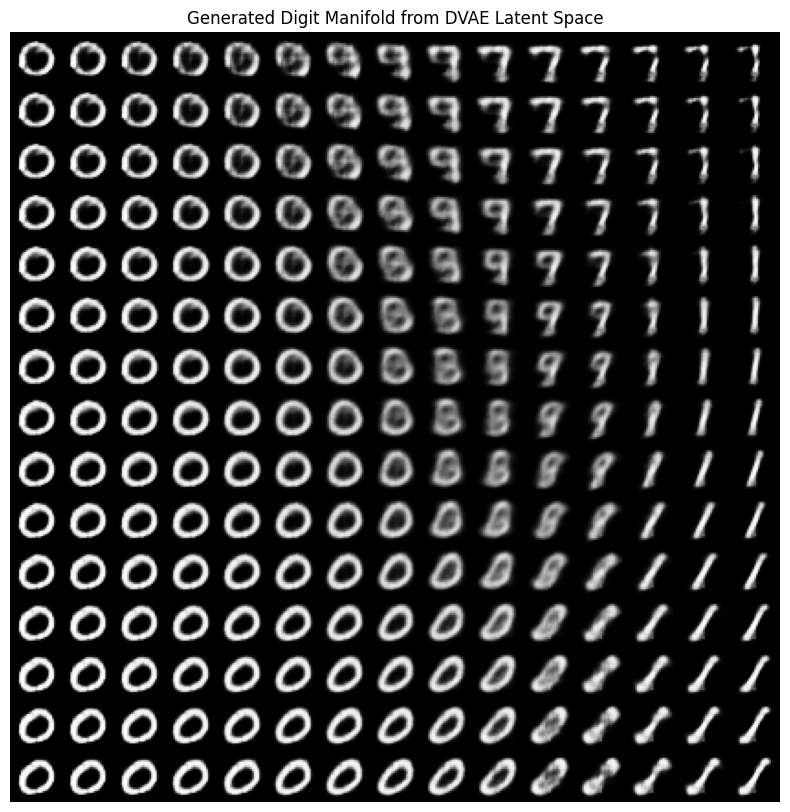

In [14]:
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
# Sample a grid of points in the latent space
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = dvae_decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="Greys_r")
plt.title("Generated Digit Manifold from DVAE Latent Space")
plt.axis("off")
plt.show()